In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()



Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
df.shape

(32581, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [12]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [13]:
df.fillna(df.median(numeric_only=True),inplace = True)

In [14]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print(categorical_columns)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [17]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [18]:
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade'
]

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

In [19]:
df

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,123.0,35000,16.02,1,0.59,Y,3,0,...,0,1,0,0,0,0,1,0,0,0
1,21,9600,5.0,1000,11.14,0,0.10,N,2,0,...,0,0,0,0,1,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,N,3,1,...,1,0,0,0,0,1,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,N,2,0,...,1,0,0,0,0,1,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,Y,4,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,N,30,1,...,0,1,0,0,0,1,0,0,0,0
32577,54,120000,4.0,17625,7.49,0,0.15,N,19,1,...,0,1,0,1,0,0,0,0,0,0
32578,65,76000,3.0,35000,10.99,1,0.46,N,28,0,...,0,0,0,0,1,0,0,0,0,0
32579,56,150000,5.0,15000,11.48,0,0.10,N,26,1,...,0,1,0,0,1,0,0,0,0,0


In [20]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({
    "N": 0,
    "Y": 1
})

In [21]:
df

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,123.0,35000,16.02,1,0.59,1,3,0,...,0,1,0,0,0,0,1,0,0,0
1,21,9600,5.0,1000,11.14,0,0.10,0,2,0,...,0,0,0,0,1,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,0,3,1,...,1,0,0,0,0,1,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,0,2,0,...,1,0,0,0,0,1,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,1,4,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,0,30,1,...,0,1,0,0,0,1,0,0,0,0
32577,54,120000,4.0,17625,7.49,0,0.15,0,19,1,...,0,1,0,1,0,0,0,0,0,0
32578,65,76000,3.0,35000,10.99,1,0.46,0,28,0,...,0,0,0,0,1,0,0,0,0,0
32579,56,150000,5.0,15000,11.48,0,0.10,0,26,1,...,0,1,0,0,1,0,0,0,0,0


In [22]:
print(df.columns.tolist())

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G']


In [23]:
X = df.drop(columns=['loan_status'])   # Features
y = df['loan_status']                  # Target

In [24]:
from sklearn.model_selection import train_test_split



# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # Reproducible results
    stratify=y          # Preserve class distribution
)

In [25]:
print("Training features :", X_train.shape)
print("Testing features  :", X_test.shape)
print("Training labels   :", y_train.shape)
print("Testing labels    :", y_test.shape)

Training features : (25932, 25)
Testing features  : (6484, 25)
Training labels   : (25932,)
Testing labels    : (6484,)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8689080814312153


In [47]:
from sklearn.metrics import confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8689080814312153

Confusion Matrix:
[[4830  236]
 [ 614  804]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.65      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484



In [48]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.867883987778809


In [50]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [54]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
y_pred_rf = rf.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9341455891425047

Confusion Matrix:
[[5030   36]
 [ 391 1027]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.72      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.86      0.89      6484
weighted avg       0.94      0.93      0.93      6484


ROC-AUC: 0.9286031576421143


In [57]:
# Random forest is clearly Better

In [58]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

In [59]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [60]:
print(feature_importance)

                           Feature  Importance
5              loan_percent_income    0.219828
1                    person_income    0.144017
4                    loan_int_rate    0.113809
3                        loan_amnt    0.074844
2                person_emp_length    0.060415
11      person_home_ownership_RENT    0.054994
21                    loan_grade_D    0.053652
0                       person_age    0.045942
7       cb_person_cred_hist_length    0.034292
8   person_home_ownership_MORTGAGE    0.028216
12   loan_intent_DEBTCONSOLIDATION    0.023554
15             loan_intent_MEDICAL    0.020540
10       person_home_ownership_OWN    0.019121
20                    loan_grade_C    0.018032
22                    loan_grade_E    0.013461
14     loan_intent_HOMEIMPROVEMENT    0.012757
13           loan_intent_EDUCATION    0.011642
18                    loan_grade_A    0.011257
6        cb_person_default_on_file    0.010039
17             loan_intent_VENTURE    0.008414
16           

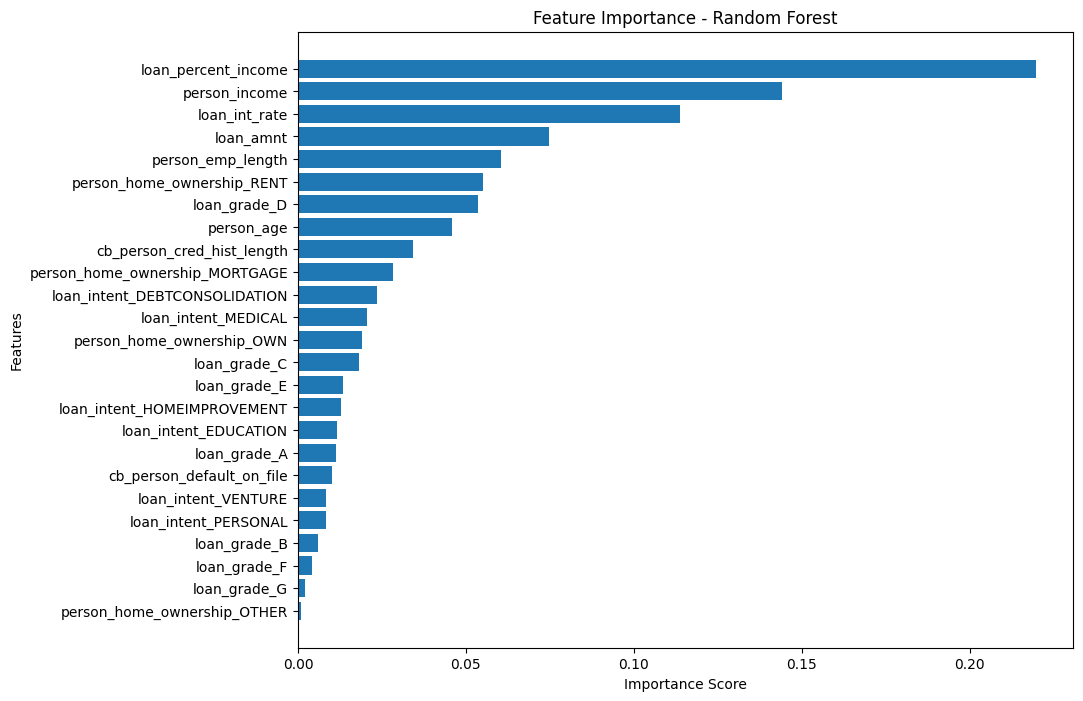

In [61]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.show()

In [62]:
top10 = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

print(top10)

                           Feature  Importance
5              loan_percent_income    0.219828
1                    person_income    0.144017
4                    loan_int_rate    0.113809
3                        loan_amnt    0.074844
2                person_emp_length    0.060415
11      person_home_ownership_RENT    0.054994
21                    loan_grade_D    0.053652
0                       person_age    0.045942
7       cb_person_cred_hist_length    0.034292
8   person_home_ownership_MORTGAGE    0.028216


In [63]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [64]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [65]:
import os

print(os.listdir())

['.config', 'credit_risk_dataset.csv', 'random_forest_model.pkl', 'scaler.pkl', 'sample_data']


In [66]:
from google.colab import files

files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Text(0.5, 1.0, 'Confusion Matrix')

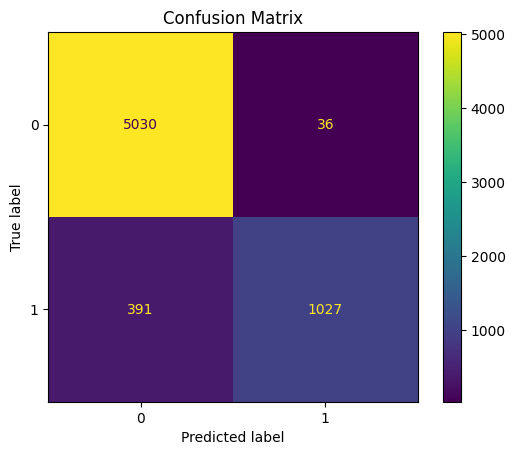

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Confusion Matrix")

In [69]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>